In [19]:
!pip install timm -q

import os
import torch
import timm
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/kaggle/input/datasets/venkatsaikondra/mswens/Final_Data_CLAHE"
print("Using device:", device)

Using device: cuda


In [21]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [22]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

class_names = train_dataset.classes
print("Classes:", class_names)

# 🔥 Handle imbalance
targets = [label for _, label in train_dataset]
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

KeyboardInterrupt: 

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
model_eff = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=4).to(device)
model_inc = timm.create_model('inception_v3', pretrained=True, num_classes=4).to(device)

In [ ]:

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_eff = optim.AdamW(model_eff.parameters(), lr=3e-4)
optimizer_inc = optim.AdamW(model_inc.parameters(), lr=3e-4)

scheduler_eff = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=30)
scheduler_inc = optim.lr_scheduler.CosineAnnealingLR(optimizer_inc, T_max=30)

In [ ]:
def train_effnet(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_eff.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer_eff.zero_grad()
            outputs = model_eff(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_eff.step()

        scheduler_eff.step()

        # VALIDATION
        model_eff.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                out = model_eff(images)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"EffNet Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_eff.state_dict(), "best_eff.pth")

    print("✅ EfficientNet Done")

train_effnet()

In [ ]:
def train_inception(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_inc.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # 🔥 resize ONLY here
            images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

            optimizer_inc.zero_grad()
            outputs = model_inc(images_299)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_inc.step()

        scheduler_inc.step()

        # VALIDATION
        model_inc.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

                out = model_inc(images_299)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"Inception Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_inc.state_dict(), "best_inc.pth")

    print("✅ Inception Done")

train_inception()

In [ ]:
model_eff.load_state_dict(torch.load("best_eff.pth", map_location=device))
model_inc.load_state_dict(torch.load("best_inc.pth", map_location=device))

model_eff.eval()
model_inc.eval()

In [23]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_eff.eval()
model_inc.eval()

# ==========================================================
# 🔥 ENSEMBLE (CORRECT - PROBABILITY LEVEL)
# ==========================================================
def ensemble_predict(images, w1, w2, boost):

    img224 = images
    img299 = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    logits1 = model_eff(img224)
    logits2 = model_inc(img299)

    p1 = torch.softmax(logits1, dim=1)
    p2 = torch.softmax(logits2, dim=1)

    # Weighted fusion
    pfusion = w1 * p1 + w2 * p2

    # Class-aware boost
    boost = boost.unsqueeze(0)
    pweighted = pfusion * boost

    # Renormalization
    pnorm = pweighted / pweighted.sum(dim=1, keepdim=True)

    return pnorm


# ==========================================================
# 🔥 SAFE TTA (FINAL VERSION)
# ==========================================================
def tta_transforms(images):

    # 1️⃣ Original
    t1 = images

    # 2️⃣ Horizontal flip
    t2 = torch.flip(images, dims=[3])

    # 3️⃣ Slight brightness increase
    t3 = torch.clamp(images * 1.03, 0, 1)

    # 4️⃣ Slight brightness decrease
    t4 = torch.clamp(images * 0.97, 0, 1)

    return [t1, t2, t3, t4]


# ==========================================================
# 🔥 TTA PREDICTION
# ==========================================================
def tta_predict(images, w1, w2, boost):

    outputs = []
    views = tta_transforms(images)

    for v in views:
        out = ensemble_predict(v, w1, w2, boost)
        outputs.append(out)

    return torch.mean(torch.stack(outputs), dim=0)


# ==========================================================
# 📊 EVALUATION FUNCTION
# ==========================================================
def evaluate_model(w1, w2, boost):

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = tta_predict(images, w1, w2, boost)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    return f1, acc


# ==========================================================
# 🔥 ABLATION: WEIGHTS × BOOST
# ==========================================================
boost_values = [1.0, 1.05, 1.1,1.15,1.20,1.25,1.30,1.35,1.40,1.45,1.50]

weight_pairs = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6,0.4),
    (0.5,0.5),
    (0.4,0.6),
    (0.3,0.7),
    (0.2,0.8),
    (0.1,0.9),
    (0.0,1.0)
    
]

results = []

for b in boost_values:

    print(f"\n🔵 Boost = {b}")

    boost = torch.tensor([1.0, 1.0, b, b], device=device)

    for w1, w2 in weight_pairs:

        f1, acc = evaluate_model(w1, w2, boost)

        print(f"   Weights {w1}/{w2} → F1: {f1:.4f} | Acc: {acc:.4f}")

        results.append({
            "Boost": b,
            "Weights": f"{w1}/{w2}",
            "F1": round(f1, 4),
            "Accuracy": round(acc, 4)
        })


# ==========================================================
# 📊 CREATE TABLES
# ==========================================================
df = pd.DataFrame(results)

pivot_f1 = df.pivot(index="Boost", columns="Weights", values="F1")
pivot_acc = df.pivot(index="Boost", columns="Weights", values="Accuracy")

print("\n📊 Macro F1 Table")
print(pivot_f1)

print("\n📊 Accuracy Table")
print(pivot_acc)


# ==========================================================
# 🏆 BEST CONFIGURATION
# ==========================================================
best_row = df.loc[df["F1"].idxmax()]

print("\n🏆 BEST CONFIGURATION")
print(best_row)


🔵 Boost = 1.0
   Weights 1.0/0.0 → F1: 0.9487 | Acc: 0.9488
   Weights 0.9/0.1 → F1: 0.9487 | Acc: 0.9488
   Weights 0.8/0.2 → F1: 0.9499 | Acc: 0.9500
   Weights 0.7/0.3 → F1: 0.9512 | Acc: 0.9512
   Weights 0.6/0.4 → F1: 0.9518 | Acc: 0.9519
   Weights 0.5/0.5 → F1: 0.9531 | Acc: 0.9531
   Weights 0.4/0.6 → F1: 0.9525 | Acc: 0.9525
   Weights 0.3/0.7 → F1: 0.9482 | Acc: 0.9481
   Weights 0.2/0.8 → F1: 0.9445 | Acc: 0.9444
   Weights 0.1/0.9 → F1: 0.9389 | Acc: 0.9389
   Weights 0.0/1.0 → F1: 0.9395 | Acc: 0.9395

🔵 Boost = 1.05
   Weights 1.0/0.0 → F1: 0.9487 | Acc: 0.9488
   Weights 0.9/0.1 → F1: 0.9493 | Acc: 0.9494
   Weights 0.8/0.2 → F1: 0.9499 | Acc: 0.9500
   Weights 0.7/0.3 → F1: 0.9512 | Acc: 0.9512
   Weights 0.6/0.4 → F1: 0.9518 | Acc: 0.9519
   Weights 0.5/0.5 → F1: 0.9525 | Acc: 0.9525
   Weights 0.4/0.6 → F1: 0.9525 | Acc: 0.9525
   Weights 0.3/0.7 → F1: 0.9482 | Acc: 0.9481
   Weights 0.2/0.8 → F1: 0.9445 | Acc: 0.9444
   Weights 0.1/0.9 → F1: 0.9389 | Acc: 0.9389
   

In [24]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_eff.eval()
model_inc.eval()

# ==========================================================
# 🔥 ENSEMBLE (CORRECT - PROBABILITY LEVEL)
# ==========================================================
def ensemble_predict(images, w1, w2, boost):

    img224 = images
    img299 = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    logits1 = model_eff(img224)
    logits2 = model_inc(img299)

    p1 = torch.softmax(logits1, dim=1)
    p2 = torch.softmax(logits2, dim=1)

    # Weighted fusion
    pfusion = w1 * p1 + w2 * p2

    # Class-aware boost
    boost = boost.unsqueeze(0)
    pweighted = pfusion * boost

    # Renormalization
    pnorm = pweighted / pweighted.sum(dim=1, keepdim=True)

    return pnorm


# ==========================================================
# 🔥 SAFE TTA (FINAL VERSION)
# ==========================================================
def tta_transforms(images):

    # 1️⃣ Original
    t1 = images

    # 2️⃣ Horizontal flip
    t2 = torch.flip(images, dims=[3])

    # 3️⃣ Slight brightness increase
    t3 = torch.clamp(images * 1.03, 0, 1)

    # 4️⃣ Slight brightness decrease
    t4 = torch.clamp(images * 0.97, 0, 1)

    return [t1, t2, t3, t4]


# ==========================================================
# 🔥 TTA PREDICTION
# ==========================================================
def tta_predict(images, w1, w2, boost):

    outputs = []
    views = tta_transforms(images)

    for v in views:
        out = ensemble_predict(v, w1, w2, boost)
        outputs.append(out)

    return torch.mean(torch.stack(outputs), dim=0)


# ==========================================================
# 📊 EVALUATION FUNCTION
# ==========================================================
def evaluate_model(w1, w2, boost):

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = tta_predict(images, w1, w2, boost)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    return f1, acc


# ==========================================================
# 🔥 ABLATION: WEIGHTS × BOOST
# ==========================================================
boost_values = [1.55, 1.60, 1.65,1.70,1.75,1.80,1.85,1.90,1.95,2.0]

weight_pairs = [
    (1.0, 0.0),
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6,0.4),
    (0.5,0.5),
    (0.4,0.6),
    (0.3,0.7),
    (0.2,0.8),
    (0.1,0.9),
    (0.0,1.0)
    
]

results = []

for b in boost_values:

    print(f"\n🔵 Boost = {b}")

    boost = torch.tensor([1.0, 1.0, b, b], device=device)

    for w1, w2 in weight_pairs:

        f1, acc = evaluate_model(w1, w2, boost)

        print(f"   Weights {w1}/{w2} → F1: {f1:.4f} | Acc: {acc:.4f}")

        results.append({
            "Boost": b,
            "Weights": f"{w1}/{w2}",
            "F1": round(f1, 4),
            "Accuracy": round(acc, 4)
        })


# ==========================================================
# 📊 CREATE TABLES
# ==========================================================
df = pd.DataFrame(results)

pivot_f1 = df.pivot(index="Boost", columns="Weights", values="F1")
pivot_acc = df.pivot(index="Boost", columns="Weights", values="Accuracy")

print("\n📊 Macro F1 Table")
print(pivot_f1)

print("\n📊 Accuracy Table")
print(pivot_acc)


# ==========================================================
# 🏆 BEST CONFIGURATION
# ==========================================================
best_row = df.loc[df["F1"].idxmax()]

print("\n🏆 BEST CONFIGURATION")
print(best_row)


🔵 Boost = 1.55
   Weights 1.0/0.0 → F1: 0.9494 | Acc: 0.9494
   Weights 0.9/0.1 → F1: 0.9500 | Acc: 0.9500
   Weights 0.8/0.2 → F1: 0.9513 | Acc: 0.9512
   Weights 0.7/0.3 → F1: 0.9544 | Acc: 0.9543
   Weights 0.6/0.4 → F1: 0.9532 | Acc: 0.9531
   Weights 0.5/0.5 → F1: 0.9526 | Acc: 0.9525
   Weights 0.4/0.6 → F1: 0.9520 | Acc: 0.9519
   Weights 0.3/0.7 → F1: 0.9494 | Acc: 0.9494
   Weights 0.2/0.8 → F1: 0.9439 | Acc: 0.9438
   Weights 0.1/0.9 → F1: 0.9395 | Acc: 0.9395
   Weights 0.0/1.0 → F1: 0.9390 | Acc: 0.9389

🔵 Boost = 1.6
   Weights 1.0/0.0 → F1: 0.9494 | Acc: 0.9494
   Weights 0.9/0.1 → F1: 0.9506 | Acc: 0.9506
   Weights 0.8/0.2 → F1: 0.9513 | Acc: 0.9512
   Weights 0.7/0.3 → F1: 0.9544 | Acc: 0.9543
   Weights 0.6/0.4 → F1: 0.9532 | Acc: 0.9531
   Weights 0.5/0.5 → F1: 0.9526 | Acc: 0.9525
   Weights 0.4/0.6 → F1: 0.9520 | Acc: 0.9519
   Weights 0.3/0.7 → F1: 0.9494 | Acc: 0.9494
   Weights 0.2/0.8 → F1: 0.9439 | Acc: 0.9438
   Weights 0.1/0.9 → F1: 0.9395 | Acc: 0.9395
   

In [25]:
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(all_labels, all_preds):
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)
    return f1, acc

In [26]:
def evaluate_predictions(get_outputs_fn):

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = get_outputs_fn(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return compute_metrics(all_labels, all_preds)

In [27]:
def effnet_only(images):
    logits = model_eff(images)
    return torch.softmax(logits, dim=1)

f1, acc = evaluate_predictions(effnet_only)
print("EffNet only:", f1, acc)

EffNet only: 0.9480934523814782 0.9481481481481482


In [28]:
def inception_only(images):
    img299 = F.interpolate(images, size=(299, 299))
    logits = model_inc(img299)
    return torch.softmax(logits, dim=1)

f1, acc = evaluate_predictions(inception_only)
print("Inception only:", f1, acc)

Inception only: 0.8790131828919139 0.8820987654320988


In [29]:
def simple_average(images):

    img299 = F.interpolate(images, size=(299, 299))

    p1 = torch.softmax(model_eff(images), dim=1)
    p2 = torch.softmax(model_inc(img299), dim=1)

    return (p1 + p2) / 2

f1, acc = evaluate_predictions(simple_average)
print("Simple Average:", f1, acc)

Simple Average: 0.944956054904721 0.9450617283950618


In [30]:
def weighted_no_boost(images):

    w1, w2 = 0.7, 0.3
    img299 = F.interpolate(images, size=(299, 299))

    p1 = torch.softmax(model_eff(images), dim=1)
    p2 = torch.softmax(model_inc(img299), dim=1)

    return w1 * p1 + w2 * p2

f1, acc = evaluate_predictions(weighted_no_boost)
print("Weighted (no boost):", f1, acc)

Weighted (no boost): 0.9481172916405147 0.9481481481481482


In [31]:
def weighted_with_boost(images):

    w1, w2 = 0.7, 0.3
    boost = torch.tensor([1.0, 1.0, 1.5, 1.5], device=device)

    img299 = F.interpolate(images, size=(299, 299))

    p1 = torch.softmax(model_eff(images), dim=1)
    p2 = torch.softmax(model_inc(img299), dim=1)

    pf = w1 * p1 + w2 * p2

    pf = pf * boost.unsqueeze(0)
    pf = pf / pf.sum(dim=1, keepdim=True)

    return pf

f1, acc = evaluate_predictions(weighted_with_boost)
print("Weighted + Boost:", f1, acc)

Weighted + Boost: 0.9481444607478018 0.9481481481481482


In [32]:
def full_without_tta(images):
    return weighted_with_boost(images)

f1, acc = evaluate_predictions(full_without_tta)
print("Full without TTA:", f1, acc)

Full without TTA: 0.9481444607478018 0.9481481481481482


In [33]:
def tta(images):

    t1 = images
    t2 = torch.flip(images, dims=[3])
    t3 = torch.clamp(images * 1.03, 0, 1)
    t4 = torch.clamp(images * 0.97, 0, 1)

    return [t1, t2, t3, t4]


def full_model(images):

    outputs = []

    for v in tta(images):
        out = weighted_with_boost(v)
        outputs.append(out)

    return torch.mean(torch.stack(outputs), dim=0)


f1, acc = evaluate_predictions(full_model)
print("Full MSW-EnsNet:", f1, acc)

Full MSW-EnsNet: 0.951897247850635 0.9518518518518518


In [34]:
import torch
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    cohen_kappa_score
)
from scipy import stats

# ==========================================================
# 🔥 GET PREDICTIONS FROM YOUR FINAL MODEL
# ==========================================================
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # ✅ YOUR FINAL MODEL
        outputs = tta_predict(images, w1=0.7, w2=0.3,
                              boost=torch.tensor([1.0,1.0,1.5,1.5], device=device))

        probs = outputs
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

# ==========================================================
# 📊 CONFUSION MATRIX
# ==========================================================
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

# ==========================================================
# 📊 BASIC METRICS
# ==========================================================
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"Macro F1: {f1:.4f}")

# ==========================================================
# 📊 SPECIFICITY (MULTI-CLASS)
# ==========================================================
specificities = []

for i in range(len(cm)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP + 1e-8)
    specificities.append(specificity)

specificity_macro = np.mean(specificities)
print(f"Specificity (Macro): {specificity_macro:.4f}")

# ==========================================================
# 📊 BALANCED ACCURACY
# ==========================================================
bal_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

# ==========================================================
# 📊 AUC-ROC (MULTI-CLASS)
# ==========================================================
try:
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    print(f"AUC-ROC (Macro): {auc:.4f}")
except:
    print("AUC-ROC could not be computed")

# ==========================================================
# 📊 COHEN'S KAPPA
# ==========================================================
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Cohen's Kappa: {kappa:.4f}")

# ==========================================================
# 📊 95% CONFIDENCE INTERVAL (ACCURACY)
# ==========================================================
n = len(y_true)
mean_acc = accuracy
se = np.sqrt((mean_acc * (1 - mean_acc)) / n)

ci_low = mean_acc - 1.96 * se
ci_high = mean_acc + 1.96 * se

print(f"95% CI (Accuracy): [{ci_low:.4f}, {ci_high:.4f}]")


Confusion Matrix:
 [[404   0   0   1]
 [  0 398   0   7]
 [  1   2 363  39]
 [  0   4  21 380]]

Accuracy: 0.9537
Precision (Macro): 0.9545
Recall (Macro): 0.9537
Macro F1: 0.9538
Specificity (Macro): 0.9846
Balanced Accuracy: 0.9537
AUC-ROC (Macro): 0.9913
Cohen's Kappa: 0.9383
95% CI (Accuracy): [0.9435, 0.9639]


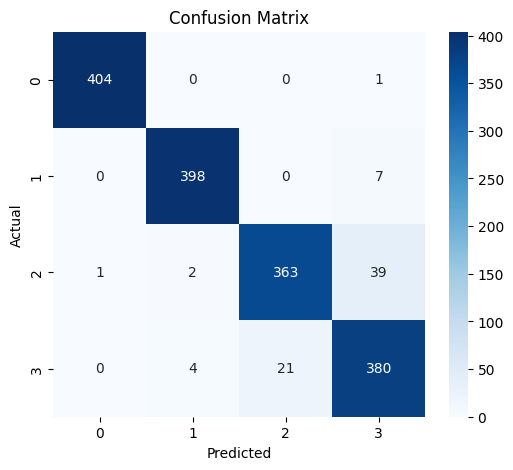

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [36]:
!pip install statsmodels

In [37]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

In [38]:
def compute_mcnemar(y_true, y_pred1, y_pred2):

    # Correct / Incorrect
    correct1 = (y_pred1 == y_true)
    correct2 = (y_pred2 == y_true)

    # Contingency table
    b = np.sum((correct1 == 1) & (correct2 == 0))
    c = np.sum((correct1 == 0) & (correct2 == 1))

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=True)

    return result.pvalue

In [39]:
y_true = []
y_eff = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        logits = model_eff(images)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)

        y_eff.extend(preds.cpu().numpy())
        y_true.extend(labels.numpy())

In [40]:
y_inc = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        img299 = F.interpolate(images, size=(299, 299))

        logits = model_inc(img299)
        preds = torch.argmax(torch.softmax(logits, dim=1), dim=1)

        y_inc.extend(preds.cpu().numpy())

In [41]:
y_msw = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = tta_predict(images, w1=0.7, w2=0.3,
                             boost=torch.tensor([1.0,1.0,1.5,1.5], device=device))

        preds = torch.argmax(outputs, dim=1)
        y_msw.extend(preds.cpu().numpy())

In [43]:
y_true = np.array(y_true)
y_eff = np.array(y_eff)
y_inc = np.array(y_inc)
y_msw = np.array(y_msw)

p_eff = compute_mcnemar(y_true, y_eff, y_msw)
p_inc = compute_mcnemar(y_true, y_inc, y_msw)

print("EffNet vs MSW p-value:", p_eff)
print("Inception vs MSW p-value:", p_inc)

EffNet vs MSW p-value: 0.0224609375
Inception vs MSW p-value: 4.048513040311289e-21
